<a href="https://colab.research.google.com/github/ale66/learn-datascience/blob/main/week-9/Ranking_premier_league/worldcup2026_ranking_notebook_prepare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Cup 2026 Ranking Analysis: Massey's and Keener's Methods

This notebook applies and compares two distinct ranking methods, Massey's Method and Keener's Method, to the 2025 club World Cup match data. The goal is to calculate and analyze team ratings and rankings based on these statistical models, providing a prediction to world cup 2026.

### **Notebook Structure:**

1.  **Data Import and Preprocessing:** Loading the Club World Cup 2025 match data and preparing it for analysis.
2.  **Massey's Ranking Method:** Implementation and analysis of Massey's method.
3.  **Keener's Ranking Method:** Implementation and analysis of Keener's method.
4.  **World Cup Simulation (Monte Carlo)**
5.  **Comparison of Ranking Methods:** A comparative view of the results from both methods against actual rankings.

## 1: Download + Read Data

We use the 2025 Club World Cup to help estimate outcomes for the 2026 World Cup because detailed and consolidated 2026 national team data is still fragmented and difficult to obtain at scale. Club-level competitions, however, provide frequent, high-quality matches across different football systems, and by mapping clubs to their countries, we can use these cross-league results as a proxy for national team strength, giving us a more stable prior for modeling and simulating the 2026 World Cup.


###  Parse + Clean (The Most Critical Step)

Goal: Transform into this table

| home | away | home_score | away_score |

In [31]:
import requests
import pandas as pd

url = "https://raw.githubusercontent.com/openfootball/worldcup.json/master/2025/clubworldcup.json"
data = requests.get(url).json()

matches = []

# CASE 1: dict with "rounds"
if isinstance(data, dict) and "rounds" in data:
    source = []
    for r in data["rounds"]:
        source.extend(r["matches"])

# CASE 2: dict with "matches"
elif isinstance(data, dict) and "matches" in data:
    source = data["matches"]

# CASE 3: list
elif isinstance(data, list):
    source = data

else:
    raise ValueError("Unknown JSON structure")

# extract raw matches (no mapping here)
for m in source:
    if "score" in m and "ft" in m["score"]:
        matches.append({
            "home": m["team1"],
            "away": m["team2"],
            "home_score": m["score"]["ft"][0],
            "away_score": m["score"]["ft"][1]
        })

df = pd.DataFrame(matches)

df.head()

,home,away,home_score,away_score
0,Al Ahly SC (EGY),Inter Miami CF (USA),0,0
1,Palmeiras (BRA),FC Porto (POR),0,0
2,Palmeiras (BRA),Al Ahly SC (EGY),2,0
3,Inter Miami CF (USA),FC Porto (POR),2,1
4,Inter Miami CF (USA),Palmeiras (BRA),2,2


In [32]:
# =========================
# Club → Country mapping
# =========================

def extract_country(team):
    if "(" in team and ")" in team:
        return team.split("(")[-1].replace(")", "").strip()
    return team  # fallback

# overwrite columns in-place (important: keeps pipeline unchanged)
df["home"] = df["home"].apply(extract_country)
df["away"] = df["away"].apply(extract_country)

df.head()

,home,away,home_score,away_score
0,EGY,USA,0,0
1,BRA,POR,0,0
2,BRA,EGY,2,0
3,USA,POR,2,1
4,USA,BRA,2,2


## 2: Massey Ratings (Linear Algebra Version)
Core Formula: Mr=p

*   M = match matrix
*   r = ratings
*   p = goal difference

### Construct Massey Matrix

1. Teams

In [33]:
teams = list(set(df["home"]).union(set(df["away"])))
n = len(teams)

team_index = {team: i for i, team in enumerate(teams)}

2. Fill Matrix

In [34]:
import numpy as np

M = np.zeros((n, n))
p = np.zeros(n)

In [35]:
for _, row in df.iterrows():

    h = team_index[row["home"]]
    a = team_index[row["away"]]

    hs = row["home_score"]
    aw = row["away_score"]

    # Massey structure
    M[h, h] += 1
    M[a, a] += 1
    M[h, a] -= 1
    M[a, h] -= 1

    p[h] += hs - aw
    p[a] += aw - hs

3. Constraint (Very Important)

In [36]:
M[-1, :] = 1
p[-1] = 0

4. Solve

In [37]:
ratings_massey = np.linalg.lstsq(M, p, rcond=None)[0]

5. Output

In [38]:
massey_df = pd.DataFrame({
    "team": teams,
    "massey": ratings_massey
}).sort_values("massey", ascending=False)

print(massey_df.head(10))

   team    massey
18  FRA  3.015277
9   ENG  2.254312
14  GER  1.564120
5   BRA  1.550266
12  ESP  1.454761
4   KSA  1.280328
11  RSA  1.057193
16  POR  0.887551
15  USA  0.414361
0   EGY  0.284059


## 3: Keener Ratings (Eigenvector)
Core Idea:
Ar=λr

In [39]:
A = np.zeros((n, n))

for _, row in df.iterrows():
    i = team_index[row["home"]]
    j = team_index[row["away"]]

    A[i, j] += row["home_score"] + 1
    A[j, i] += row["away_score"] + 1

# normalize
col_sum = A.sum(axis=0)
A = A / col_sum

### Calculate Eigenvector

In [40]:
import numpy as np
import pandas as pd

eigvals, eigvecs = np.linalg.eig(A)

idx = np.argmax(eigvals.real)

keener_ratings = eigvecs[:, idx].real

# Key: Standardize (non-negative + normalize)
keener_ratings = np.abs(keener_ratings)
keener_ratings = keener_ratings / keener_ratings.sum()

keener_df = pd.DataFrame({
    "team": teams,
    "rating": keener_ratings
}).sort_values("rating", ascending=False)

print(keener_df.head(10))

   team    rating
5   BRA  0.164515
9   ENG  0.128815
14  GER  0.090899
12  ESP  0.082124
18  FRA  0.081524
15  USA  0.079979
16  POR  0.054070
10  ITA  0.052345
4   KSA  0.044639
3   MEX  0.041787


## 4: World Cup Simulation (Monte Carlo)

In [41]:
massey_score = massey_df.set_index("team")["massey"].to_dict()

In [42]:
keener_score = keener_df.set_index("team")["rating"].to_dict()

But first, a smoothing step:

In [43]:
def normalize(score_dict):
    vals = np.array(list(score_dict.values()))
    mean = vals.mean()
    std = vals.std()

    return {k: (v - mean) / std for k, v in score_dict.items()}

In [44]:
massey_norm = normalize(massey_score)
keener_norm = normalize(keener_score)

Add "World Cup Strength Scaling"

In [45]:
def squash(score_dict, alpha=0.6):
    return {k: np.tanh(alpha * v) for k, v in score_dict.items()}

massey_wc = squash(massey_norm)
keener_wc = squash(keener_norm)

Convert to "World Cup Win Probability Model"

In [46]:
def prob(a, b, score):
    return 1 / (1 + np.exp(-(score[a] - score[b])))

### Now we can simulate the World Cup

In [47]:
def match(a, b, score):
    p = prob(a, b, score)
    return a if random.random() < p else b

In [48]:
def match_massey(a, b):
    return match(a, b, massey_wc)

In [49]:
def match_keener(a, b):
    return match(a, b, keener_wc)

In [50]:
import random

def tournament(teams, match_func):
    """
    Simulates a single-elimination tournament.

    Args:
        teams (list): A list of team names participating in the tournament.
        match_func (function): A function that takes two team names and returns the winner.

    Returns:
        str: The name of the winning team.
    """
    current_teams = list(teams)

    while len(current_teams) > 1:
        next_round_teams = []
        # Ensure an even number of teams for pairing, if odd, one team gets a bye
        for i in range(0, len(current_teams), 2):
            if i + 1 < len(current_teams):
                team1 = current_teams[i]
                team2 = current_teams[i+1]
                winner = match_func(team1, team2)
                next_round_teams.append(winner)
            else:
                # Bye for the last team if there's an odd number of teams
                next_round_teams.append(current_teams[i])
        current_teams = next_round_teams

    return current_teams[0] if current_teams else None

In [51]:
def simulate(match_func, teams, n=5000):
    from collections import Counter
    res = Counter()

    for _ in range(n):
        winner = tournament(teams, match_func)
        res[winner] += 1

    return res

### Select Participating Teams

In [52]:
teams = list(massey_df["team"])

###  Massey World Cup Simulation

In [53]:
massey_result = simulate(match_massey, teams, n=5000)

print("===== MASSEY WORLD CUP =====")
for team, count in massey_result.most_common(10):
    print(team, count / 5000)

===== MASSEY WORLD CUP =====
FRA 0.098
MAR 0.0868
JPN 0.072
ENG 0.0696
UAE 0.0624
ESP 0.0568
BRA 0.0542
RSA 0.0526
GER 0.052
KSA 0.0504


### Keener World Cup Simulation

In [54]:
keener_result = simulate(match_keener, teams, n=5000)

print("===== KEENER WORLD CUP =====")
for team, count in keener_result.most_common(10):
    print(team, count / 5000)

===== KEENER WORLD CUP =====
BRA 0.1348
ENG 0.1028
USA 0.0948
NZL 0.08
MAR 0.0778
ESP 0.0748
JPN 0.0708
UAE 0.0694
GER 0.0518
FRA 0.0466


## 5: Comparing Massey and Keener Results

Both Massey and Keener ratings show France and Argentina as strong contenders, but their relative probabilities and the ranking of other teams differ. Let's create a combined view to compare them more directly.


--- Top 10 Teams Comparison (Probability of Winning World Cup) ---


,team,massey_prob,keener_prob
3,FRA,0.0980,0.0466
7,MAR,0.0868,0.0778
5,JPN,0.0720,0.0708
1,ENG,0.0696,0.1028
10,UAE,0.0624,0.0694
2,ESP,0.0568,0.0748
0,BRA,0.0542,0.1348
9,RSA,0.0526,0.0000
4,GER,0.0520,0.0518
6,KSA,0.0504,0.0000


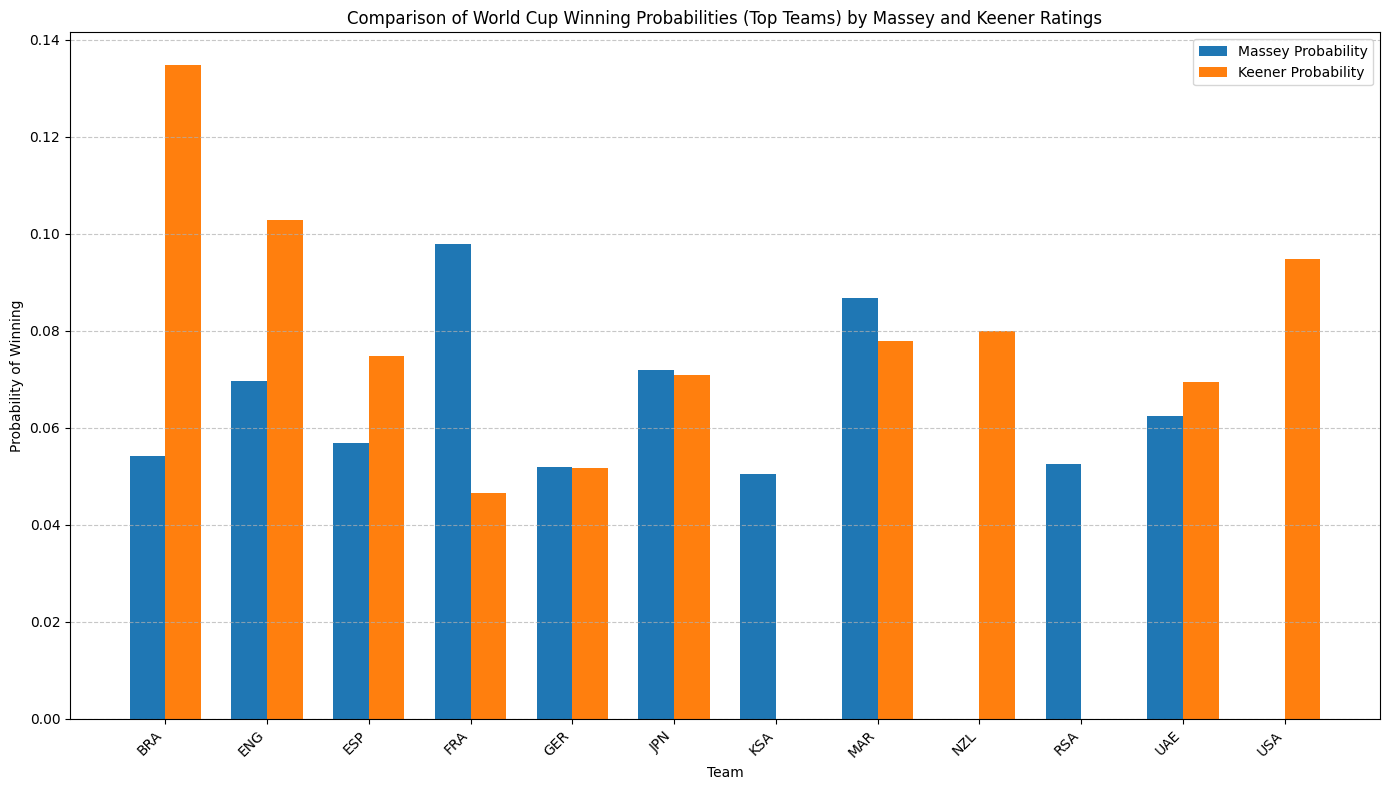

In [55]:
import matplotlib.pyplot as plt
import numpy as np

massey_prob_df = pd.DataFrame({
    'team': [team for team, count in massey_result.most_common(10)],
    'massey_prob': [count / 5000 for team, count in massey_result.most_common(10)]
})

keener_prob_df = pd.DataFrame({
    'team': [team for team, count in keener_result.most_common(10)],
    'keener_prob': [count / 5000 for team, count in keener_result.most_common(10)]
})

# Merge the dataframes on 'team' for comparison
comparison_df = pd.merge(massey_prob_df, keener_prob_df, on='team', how='outer').fillna(0)

print("\n--- Top 10 Teams Comparison (Probability of Winning World Cup) ---")
display(comparison_df.sort_values(by=['massey_prob', 'keener_prob'], ascending=False))

# Visualize the comparison
fig, ax = plt.subplots(figsize=(14, 8))

bar_width = 0.35
index = np.arange(len(comparison_df))

bar1 = ax.bar(index, comparison_df['massey_prob'], bar_width, label='Massey Probability')
bar2 = ax.bar(index + bar_width, comparison_df['keener_prob'], bar_width, label='Keener Probability')

ax.set_xlabel('Team')
ax.set_ylabel('Probability of Winning')
ax.set_title('Comparison of World Cup Winning Probabilities (Top Teams) by Massey and Keener Ratings')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(comparison_df['team'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6: 2026 World Cup Teams

The following URL provides information on the confirmed participating teams for the 2026 World Cup. Once the competition begins, actual match information will be updated here, making predictive analyses feasible. Maybe it is interesting to track these updates and then perform predictive analyses accordingly.

In [56]:
import requests
import pandas as pd

# URL for 2026 World Cup data
url_2026 = "https://raw.githubusercontent.com/openfootball/worldcup.json/master/2026/worldcup.json"
data_2026 = requests.get(url_2026).json()

matches_2026 = []

# Logic to parse the JSON data
if isinstance(data_2026, dict) and "rounds" in data_2026:
    source_2026 = []
    for r in data_2026["rounds"]:
        source_2026.extend(r["matches"])
elif isinstance(data_2026, dict) and "matches" in data_2026:
    source_2026 = data_2026["matches"]
elif isinstance(data_2026, list):
    source_2026 = data_2026
else:
    raise ValueError("Unknown JSON structure for 2026 data")

# Extract match information for 2026
for m in source_2026:
    # For prediction, we only need team names to generate ratings.
    # For now, let's just get the teams to build the rating matrix.
    if "team1" in m and "team2" in m:
        # Since we are predicting, we might not have scores. We'll use a dummy score for matrix construction if needed,
        # but for initial team identification, team names are enough.
        matches_2026.append({
            "home": m["team1"],
            "away": m["team2"],
            # Placeholder scores - these will be used to build a 'match matrix' for ratings
            # For real predictions, these would come from historical data or pre-tournament matches.
            "home_score": 0,
            "away_score": 0
        })

df_2026 = pd.DataFrame(matches_2026)

display(df_2026.head())

,home,away,home_score,away_score
0,Mexico,South Africa,0,0
1,South Korea,Czech Republic,0,0
2,Czech Republic,South Africa,0,0
3,Mexico,South Korea,0,0
4,Czech Republic,Mexico,0,0


### Note：
In our 2025 dataset, we map 20 teams from the Club World Cup to their corresponding countries, while the full World Cup format includes 32 national teams. Although the coverage is not complete, these 20 teams largely represent the highest tier of global football strength, as they are drawn from top clubs across the major leagues and confederations. This means the dataset captures most of the elite-level signal in world football.

However, the remaining teams in a full World Cup setup are not necessarily weak, as international tournaments often include mid-tier teams and potential dark horses, which can introduce additional variability and upset risk that is not fully reflected in the club-based sample.
